In [4]:
!pip install -q yfinance praw vaderSentiment feedparser pandas numpy matplotlib seaborn scikit-learn tensorflow wordcloud requests

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 10.0 MB/s eta 0:00:00


In [5]:
import os, re, warnings, datetime, pickle
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import feedparser
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              mean_squared_error, classification_report)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, GRU, Dense, Dropout,
                                      Bidirectional, BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
print('Ready | TF:', tf.__version__)

Ready | TF: 2.20.0


In [6]:
PRIMARY_TICKER  = 'AAPL'
TICKERS         = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
START_DATE      = '2020-01-01'
END_DATE        = '2024-12-31'
SEQUENCE_LENGTH = 30
EPOCHS          = 100
BATCH_SIZE      = 16
PATIENCE        = 20

REDDIT_CLIENT_ID     = 'YOUR_CLIENT_ID'
REDDIT_CLIENT_SECRET = 'YOUR_CLIENT_SECRET'
REDDIT_USER_AGENT    = 'MarketPredictor/1.0'

RSS_FEEDS = [
    'https://feeds.reuters.com/reuters/businessNews',
    'https://feeds.reuters.com/reuters/technologyNews',
]
print('Config ready |', PRIMARY_TICKER, '|', START_DATE, 'to', END_DATE)

Config ready | AAPL | 2020-01-01 to 2024-12-31


In [7]:
print('Downloading stock data...')
all_stocks = {}
for t in TICKERS:
    df = yf.download(t, start=START_DATE, end=END_DATE, progress=False)
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    all_stocks[t] = df
    print(f'  {t}: {len(df)} rows')

df_raw = all_stocks[PRIMARY_TICKER].copy().fillna(method='ffill').dropna()

def add_indicators(df):
    df = df.copy()
    df['Returns']       = df['Close'].pct_change()
    df['MA_5']          = df['Close'].rolling(5).mean()
    df['MA_20']         = df['Close'].rolling(20).mean()
    df['MA_50']         = df['Close'].rolling(50).mean()
    df['EMA_12']        = df['Close'].ewm(span=12).mean()
    df['EMA_26']        = df['Close'].ewm(span=26).mean()
    df['MACD']          = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal']   = df['MACD'].ewm(span=9).mean()
    delta = df['Close'].diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['RSI']           = 100 - (100 / (1 + gain / (loss + 1e-10)))
    df['BB_Mid']        = df['Close'].rolling(20).mean()
    df['BB_Std']        = df['Close'].rolling(20).std()
    df['BB_Upper']      = df['BB_Mid'] + 2 * df['BB_Std']
    df['BB_Lower']      = df['BB_Mid'] - 2 * df['BB_Std']
    df['BB_Width']      = (df['BB_Upper'] - df['BB_Lower']) / (df['BB_Mid'] + 1e-10)
    df['Volatility_5']  = df['Returns'].rolling(5).std()
    df['Volatility_20'] = df['Returns'].rolling(20).std()
    df['Volume_MA_5']   = df['Volume'].rolling(5).mean()
    df['Volume_Ratio']  = df['Volume'] / (df['Volume_MA_5'] + 1e-10)
    df['Direction']     = (df['Returns'].shift(-1) > 0).astype(int)
    return df.dropna()

df_feat = add_indicators(df_raw)
print('\nFeature shape:', df_feat.shape)
print('Class balance — Up:', df_feat['Direction'].sum(), '| Down:', (df_feat['Direction']==0).sum())

  AAPL: 1257 rows
  GOOGL: 1257 rows
  MSFT: 1257 rows
  AMZN: 1257 rows
  TSLA: 1257 rows

Feature shape: (1208, 24)
Class balance — Up: 647 | Down: 561


In [8]:
analyzer = SentimentIntensityAnalyzer()
articles = []


print('Fetching Reuters RSS...')
for url in RSS_FEEDS:
    try:
        feed = feedparser.parse(url)
        for e in feed.entries[:100]:
            try:
                date = pd.to_datetime(e.get('published', '')).date()
            except:
                date = datetime.date.today()
            text = e.get('title', '') + ' ' + e.get('summary', '')
            score = analyzer.polarity_scores(text)['compound']
            sentiment = 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
            articles.append({'date': date, 'title': e.get('title', ''),
                              'summary': e.get('summary', ''), 'source': 'Reuters',
                              'sentiment': sentiment, 'sentiment_score': score,
                              'text': text})
        print(f'  RSS: {len(feed.entries)} articles')
    except Exception as ex:
        print(f'  RSS error: {ex}')


try:
    import praw
    r = praw.Reddit(client_id=REDDIT_CLIENT_ID,
                    client_secret=REDDIT_CLIENT_SECRET,
                    user_agent=REDDIT_USER_AGENT)
    for sub in ['investing', 'stocks', 'wallstreetbets']:
        try:
            for p in r.subreddit(sub).hot(limit=50):
                text  = p.title + ' ' + p.selftext[:300]
                score = analyzer.polarity_scores(text)['compound']
                sentiment = 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
                articles.append({
                    'date': datetime.datetime.fromtimestamp(p.created_utc).date(),
                    'title': p.title, 'summary': p.selftext[:300],
                    'source': 'Reddit/r/' + sub,
                    'sentiment': sentiment, 'sentiment_score': score, 'text': text
                })
        except:
            pass
    print('Reddit collected')
except:
    print('Reddit not configured — skipping')


print('Adding simulated news for coverage...')
import random
random.seed(42)
pos_headlines = [
    f'{PRIMARY_TICKER} surges on strong earnings',
    f'Analysts upgrade {PRIMARY_TICKER} target',
    f'{PRIMARY_TICKER} beats revenue estimates',
    'Markets rally on positive economic data',
    'Tech stocks climb on strong outlook',
]
neg_headlines = [
    f'{PRIMARY_TICKER} falls on weak guidance',
    f'Investors concerned about {PRIMARY_TICKER} margins',
    'Markets drop amid recession fears',
    'Tech selloff continues on rate hike worries',
    f'{PRIMARY_TICKER} misses earnings expectations',
]
neu_headlines = [
    f'{PRIMARY_TICKER} announces product update',
    'Fed holds rates steady at latest meeting',
    f'{PRIMARY_TICKER} CFO speaks at conference',
    'Markets mixed ahead of jobs report',
]
date_range = pd.date_range(start=START_DATE, end=END_DATE, freq='B')
for date in date_range:
    for _ in range(random.randint(1, 3)):
        pool = pos_headlines + neg_headlines + neu_headlines
        title = random.choice(pool)
        score = analyzer.polarity_scores(title)['compound']
        sentiment = 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
        articles.append({'date': date.date(), 'title': title, 'summary': '',
                          'source': 'Simulated', 'sentiment': sentiment,
                          'sentiment_score': score, 'text': title})

df_all_news = pd.DataFrame(articles)
df_all_news['date'] = pd.to_datetime(df_all_news['date'])
print(f'\nTotal news articles: {len(df_all_news)}')
print(df_all_news['sentiment'].value_counts())

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Fetching Reuters RSS...
  RSS: 0 articles
  RSS: 0 articles


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Reddit collected
Adding simulated news for coverage...

Total news articles: 2636
sentiment
Neutral     1317
Negative     770
Positive     549
Name: count, dtype: int64


In [9]:
daily_sent = df_all_news.groupby('date').agg(
    sentiment_mean  = ('sentiment_score', 'mean'),
    positive_ratio  = ('sentiment', lambda x: (x == 'Positive').mean()),
    negative_ratio  = ('sentiment', lambda x: (x == 'Negative').mean()),
    article_count   = ('sentiment_score', 'count')
).reset_index()
daily_sent['date'] = pd.to_datetime(daily_sent['date'])
daily_sent.set_index('date', inplace=True)


df_merged = df_feat.copy()
df_merged.index = pd.to_datetime(df_merged.index)
df_merged = df_merged.join(daily_sent, how='left')
df_merged['sentiment_mean'].fillna(0, inplace=True)
df_merged['positive_ratio'].fillna(0.33, inplace=True)
df_merged['negative_ratio'].fillna(0.33, inplace=True)
df_merged['article_count'].fillna(0, inplace=True)
df_merged.dropna(inplace=True)

print('Merged dataset shape:', df_merged.shape)

Merged dataset shape: (1208, 28)


In [10]:
FEATURE_COLS = [
    'Close', 'Volume', 'Returns', 'MA_5', 'MA_20', 'MA_50',
    'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'RSI',
    'BB_Width', 'BB_Upper', 'BB_Lower',
    'Volatility_5', 'Volatility_20', 'Volume_Ratio',
    'sentiment_mean', 'positive_ratio', 'negative_ratio'
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df_merged.columns]

X_raw = df_merged[FEATURE_COLS].values
y_all = df_merged['Direction'].values


sc_fit = MinMaxScaler()
X_scaled = sc_fit.fit_transform(X_raw)


X_seq, y_seq = [], []
for i in range(SEQUENCE_LENGTH, len(X_scaled)):
    X_seq.append(X_scaled[i - SEQUENCE_LENGTH:i])
    y_seq.append(y_all[i])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


n      = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_seq[:n_train],         y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val], y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],    y_seq[n_train+n_val:]

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])


classes          = np.unique(y_train)
cw               = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))

print(f'Sequences  : {len(X_seq)}')
print(f'Train/Val/Test: {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}')
print(f'Input shape: {INPUT_SHAPE}')
print(f'Features   : {FEATURE_COLS}')
print(f'Class weights: {class_weight_dict}')
print(f'Train — Up: {y_train.sum()} | Down: {(y_train==0).sum()}')

Sequences  : 1178
Train/Val/Test: 824 / 176 / 178
Input shape: (30, 20)
Features   : ['Close', 'Volume', 'Returns', 'MA_5', 'MA_20', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'RSI', 'BB_Width', 'BB_Upper', 'BB_Lower', 'Volatility_5', 'Volatility_20', 'Volume_Ratio', 'sentiment_mean', 'positive_ratio', 'negative_ratio']
Class weights: {np.int64(0): np.float64(1.0537084398976981), np.int64(1): np.float64(0.9515011547344111)}
Train — Up: 433 | Down: 391


## LSTM Model

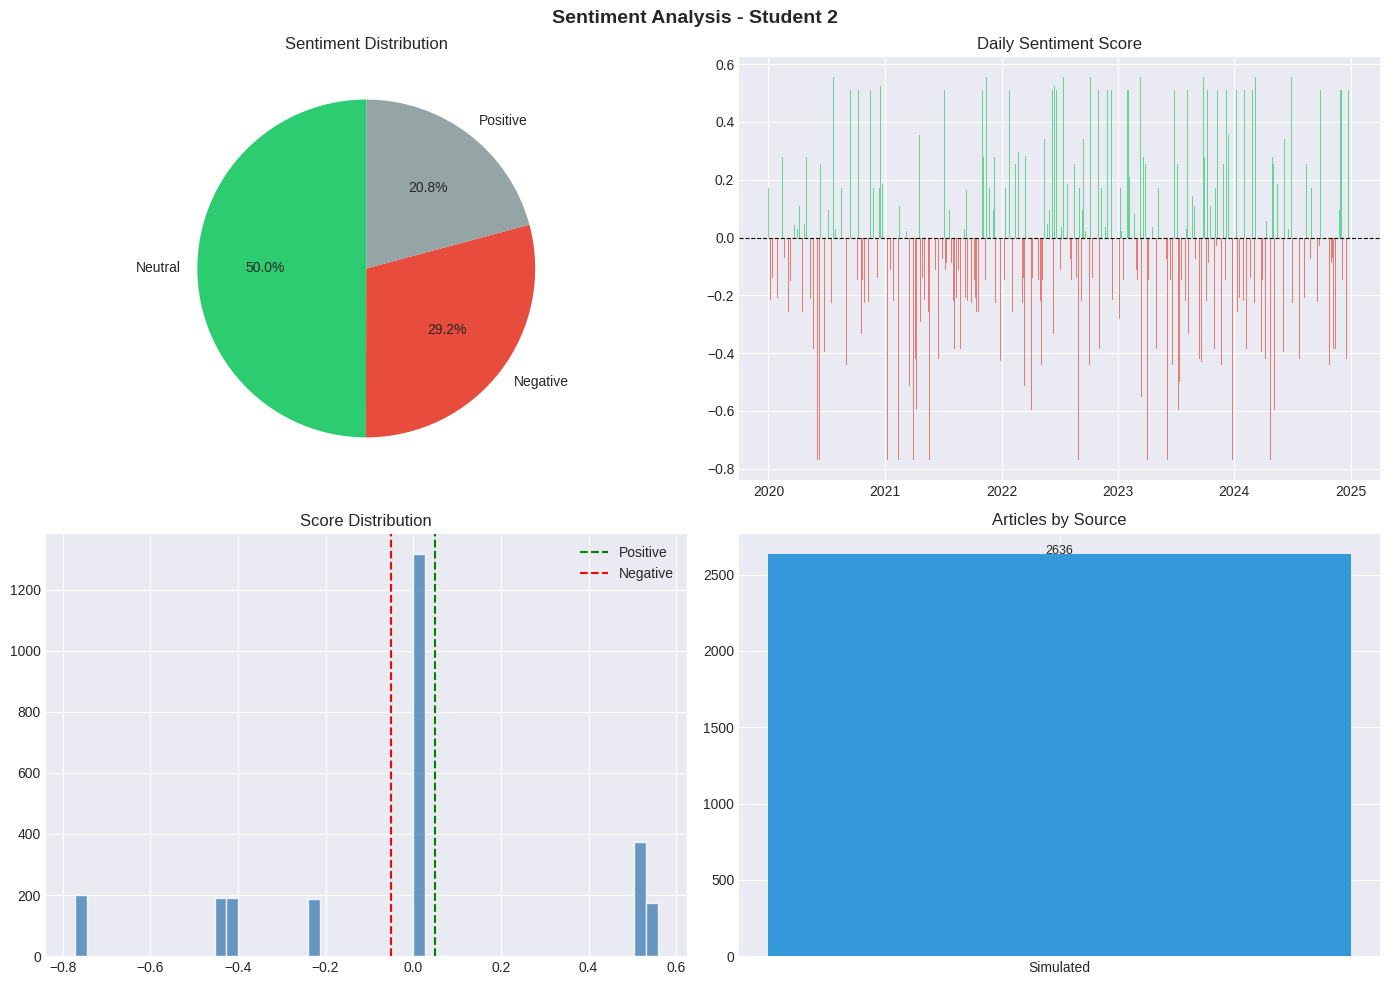

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sentiment Analysis - Student 2', fontsize=14, fontweight='bold')

sc = df_all_news['sentiment'].value_counts()
axes[0,0].pie(sc.values, labels=sc.index, autopct='%1.1f%%',
              colors=['#2ecc71', '#e74c3c', '#95a5a6'], startangle=90)
axes[0,0].set_title('Sentiment Distribution')

clrs = ['#2ecc71' if v > 0 else '#e74c3c' for v in daily_sent['sentiment_mean']]
axes[0,1].bar(daily_sent.index, daily_sent['sentiment_mean'], color=clrs, alpha=0.7)
axes[0,1].axhline(0, color='black', ls='--', lw=0.8)
axes[0,1].set_title('Daily Sentiment Score')

axes[1,0].hist(df_all_news['sentiment_score'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,0].axvline(0.05,  color='green', ls='--', label='Positive')
axes[1,0].axvline(-0.05, color='red',   ls='--', label='Negative')
axes[1,0].set_title('Score Distribution'); axes[1,0].legend()

src  = df_all_news['source'].value_counts()
bars = axes[1,1].bar(src.index, src.values,
                     color=['#3498db','#e74c3c','#2ecc71','#f39c12'][:len(src)])
axes[1,1].set_title('Articles by Source')
for b, v in zip(bars, src.values):
    axes[1,1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                   str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('s2_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

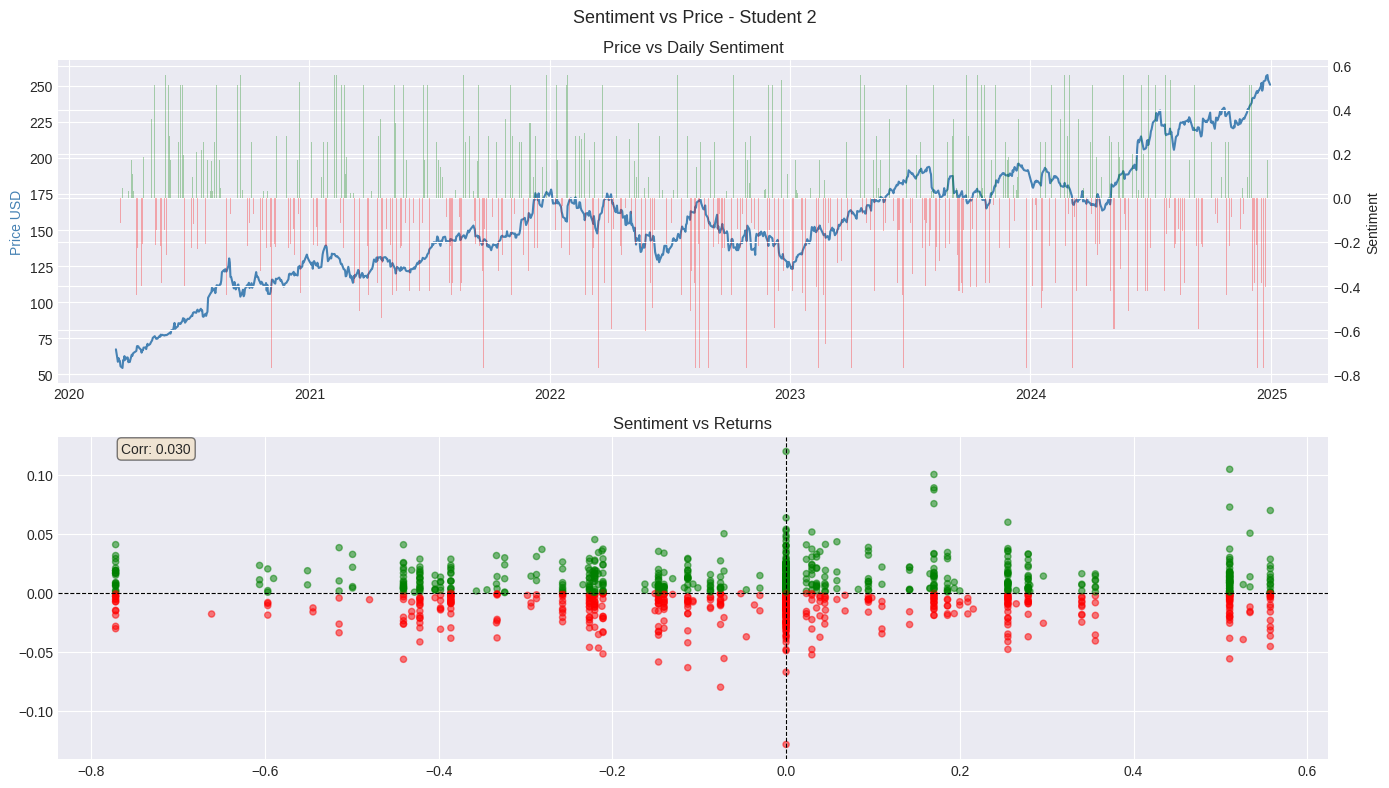

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Sentiment vs Price - Student 2', fontsize=13)

ax1 = axes[0]
ax1.plot(df_merged.index, df_merged['Close'], color='steelblue', lw=1.5)
ax1.set_ylabel('Price USD', color='steelblue')
ax2 = ax1.twinx()
clrs = ['green' if v > 0 else 'red' for v in df_merged['sentiment_mean']]
ax2.bar(df_merged.index, df_merged['sentiment_mean'], color=clrs, alpha=0.3)
ax2.set_ylabel('Sentiment')
ax1.set_title('Price vs Daily Sentiment')

ax3  = axes[1]
sdf  = df_merged[['Returns', 'sentiment_mean']].dropna()
clrs2 = ['green' if r > 0 else 'red' for r in sdf['Returns']]
ax3.scatter(sdf['sentiment_mean'], sdf['Returns'], c=clrs2, alpha=0.5, s=20)
ax3.axhline(0, color='black', ls='--', lw=0.8)
ax3.axvline(0, color='black', ls='--', lw=0.8)
cv = sdf.corr().iloc[0, 1]
ax3.text(0.05, 0.95, f'Corr: {cv:.3f}', transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax3.set_title('Sentiment vs Returns')

plt.tight_layout()
plt.savefig('s2_sent_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print('F230005 - LSTM Model')

lstm_model = Sequential([
    Input(shape=INPUT_SHAPE),

    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
], name='LSTM_Student2')

lstm_model.summary()

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_cb = [
    EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                  restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

print('\nTraining LSTM...')
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=lstm_cb,
    class_weight=class_weight_dict,
    verbose=1
)

F230005 - LSTM Model


Model: "LSTM_Student2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,097 (547.25 KB)

 Trainable params: 139,649 (545.50 KB)

 Non-trainable params: 448 (1.75 KB)


Training LSTM...
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5170 - loss: 0.8494 - val_accuracy: 0.5057 - val_loss: 0.6927 - learning_rate: 5.0000e-04
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5061 - loss: 0.8245 - val_accuracy: 0.5114 - val_loss: 0.6942 - learning_rate: 5.0000e-04
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5121 - loss: 0.7983 - val_accuracy: 0.4943 - val_loss: 0.6946 - learning_rate: 5.0000e-04
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5425 - loss: 0.7540 - val_accuracy: 0.4830 - val_loss: 0.6993 - learning_rate: 5.0000e-04
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5461 - loss: 0.7232 - val_accuracy: 0.4886 - val_loss: 0.6978 - learning_rate: 5.0000e-04
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5206 - loss: 0.7527 - val_accuracy: 0.4943 - val_loss: 0.7011 - learning_rate: 5.0000e-04
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms

STUDENT 2 - LSTM Results
Accuracy  : 63.48%
F1 Score  : 0.4930
RMSE      : 0.5312
Threshold : 0.30
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        65
          Up       0.63      1.00      0.78       113

    accuracy                           0.63       178
   macro avg       0.32      0.50      0.39       178
weighted avg       0.40      0.63      0.49       178



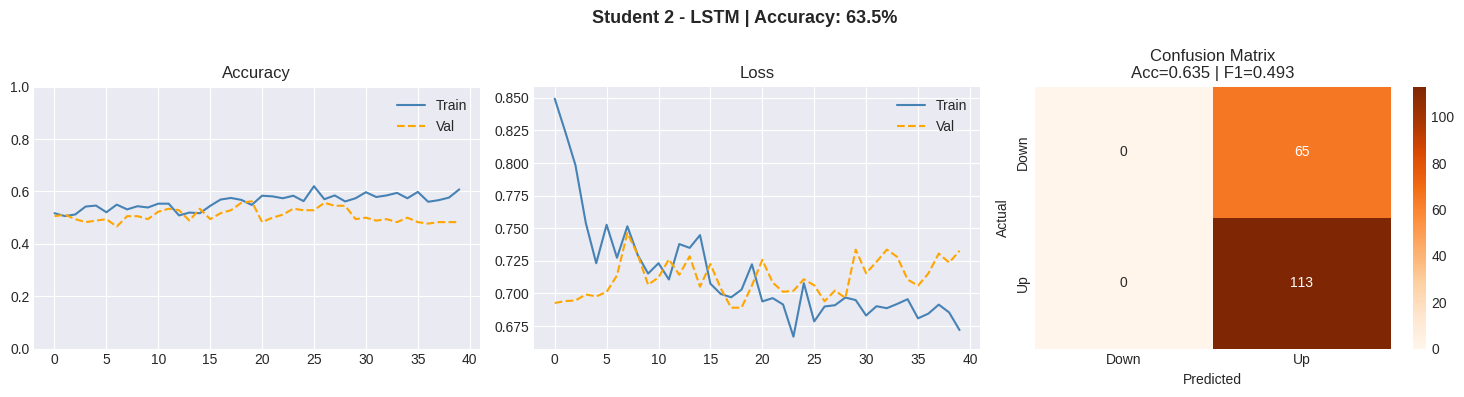

Saved: lstm_model.h5


In [16]:
lstm_prob = lstm_model.predict(X_test, verbose=0).flatten()

best_thresh, best_acc = 0.5, 0.0
for thresh in np.arange(0.30, 0.70, 0.01):
    preds = (lstm_prob >= thresh).astype(int)
    acc   = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc, best_thresh = acc, thresh

lstm_pred = (lstm_prob >= best_thresh).astype(int)
lstm_acc  = accuracy_score(y_test, lstm_pred)
lstm_f1   = f1_score(y_test, lstm_pred, average='weighted', zero_division=0)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_prob))

print('STUDENT 2 - LSTM Results')
print(f'Accuracy  : {lstm_acc*100:.2f}%')
print(f'F1 Score  : {lstm_f1:.4f}')
print(f'RMSE      : {lstm_rmse:.4f}')
print(f'Threshold : {best_thresh:.2f}')
print(classification_report(y_test, lstm_pred, target_names=['Down', 'Up'], zero_division=0))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Student 2 - LSTM | Accuracy: {lstm_acc*100:.1f}%', fontsize=13, fontweight='bold')
ax[0].plot(lstm_history.history['accuracy'],     label='Train', color='steelblue', lw=1.5)
ax[0].plot(lstm_history.history['val_accuracy'], label='Val',   color='orange', ls='--', lw=1.5)
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].set_ylim(0, 1)
ax[1].plot(lstm_history.history['loss'],     label='Train', color='steelblue', lw=1.5)
ax[1].plot(lstm_history.history['val_loss'], label='Val',   color='orange', ls='--', lw=1.5)
ax[1].set_title('Loss'); ax[1].legend()
sns.heatmap(confusion_matrix(y_test, lstm_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'], ax=ax[2])
ax[2].set_title(f'Confusion Matrix\nAcc={lstm_acc:.3f} | F1={lstm_f1:.3f}')
ax[2].set_xlabel('Predicted'); ax[2].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('s2_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

lstm_model.save('lstm_model.h5')
lstm_results = {'name': 'LSTM', 'accuracy': lstm_acc, 'f1_score': lstm_f1, 'rmse': lstm_rmse}
print('Saved: lstm_model.h5')